# 🚛 Explainable AI for Predictive Maintenance
**Scania Component X Dataset**  
Kunal Singh Dadhwal 23BDS1097 | Tapan Batla 23BDS1151  

**Model:** XGBoost Binary Classifier  
**XAI:** SHAP TreeExplainer

## 1. Environment Setup
Mount Google Drive and extract the dataset into Colab's local fast storage.

In [1]:

from google.colab import drive
drive.mount('/content/drive')

!unzip "/content/drive/MyDrive/AI_DA_PREDICTIVE MAINTAINENCE/Dataset.zip" -d "/content/Dataset/"

Mounted at /content/drive
Archive:  /content/drive/MyDrive/AI_DA_PREDICTIVE MAINTAINENCE/Dataset.zip
   creating: /content/Dataset/Dataset/
  inflating: /content/Dataset/Dataset/train_operational_readouts.csv  
  inflating: /content/Dataset/Dataset/train_specifications.csv  
  inflating: /content/Dataset/Dataset/train_tte.csv  
  inflating: /content/Dataset/Dataset/validation_labels.csv  
  inflating: /content/Dataset/Dataset/validation_operational_readouts.csv  
  inflating: /content/Dataset/Dataset/validation_specifications.csv  


## 2. Data Preprocessing
### 2.1 Relational Merging
Six CSV files are merged using `vehicle_id` as the primary key via a Left Join
to construct unified master dataframes for training and validation.

In [5]:
import pandas as pd
import numpy as np

df_train_ops = pd.read_csv('/content/Dataset/Dataset/train_operational_readouts.csv')
df_train_specs = pd.read_csv('/content/Dataset/Dataset/train_specifications.csv')
df_train_tte = pd.read_csv('/content/Dataset/Dataset/train_tte.csv')

df_val_ops = pd.read_csv('/content/Dataset/Dataset/validation_operational_readouts.csv')
df_val_specs = pd.read_csv('/content/Dataset/Dataset/validation_specifications.csv')
df_val_labels = pd.read_csv('/content/Dataset/Dataset/validation_labels.csv')

print("Files loaded successfully!")
train_merged_1 = pd.merge(df_train_ops, df_train_specs, on='vehicle_id', how='left')
master_train = pd.merge(train_merged_1, df_train_tte, on='vehicle_id', how='left')

val_merged_1 = pd.merge(df_val_ops, df_val_specs, on='vehicle_id', how='left')
master_validation = pd.merge(val_merged_1, df_val_labels, on='vehicle_id', how='left')

print(f"Master Train Shape:      {master_train.shape}")
print(f"Master Validation Shape: {master_validation.shape}")


Files loaded successfully!
Master Train Shape:      (1122452, 117)
Master Validation Shape: (196227, 116)


### 2.2 Missing Value Treatment (Temporal Imputation)
Forward Fill (`ffill`) propagates the last known sensor reading forward.
Backward Fill (`bfill`) catches leading-edge NaN values. Zero data loss, no synthetic artifacts.

In [7]:
master_train = master_train.ffill().bfill()
master_validation = master_validation.ffill().bfill()

print("Missing values in Training Data:  ", master_train.isna().sum().sum())
print("Missing values in Validation Data:", master_validation.isna().sum().sum())

Missing values in Training Data:   0
Missing values in Validation Data: 0


### 2.3 Categorical Encoding & Z-Score Standardization
OrdinalEncoder maps categorical `Spec_` columns to numeric values.  
StandardScaler (fit on training data only) normalizes sensor features to mean ≈ 0, std = 1.  
Validation data uses `transform` only — no data leakage.

In [8]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

# Encode categorical Spec columns
spec_cols = [col for col in master_train.columns if col.startswith('Spec_')]
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
master_train[spec_cols]      = oe.fit_transform(master_train[spec_cols].astype(str))
master_validation[spec_cols] = oe.transform(master_validation[spec_cols].astype(str))

# Identify sensor columns for scaling
common_cols     = [col for col in master_train.columns if col in master_validation.columns]
numeric_cols    = master_train[common_cols].select_dtypes(include=['float64', 'int64']).columns
cols_to_exclude = ['vehicle_id', 'time_step', 'class_label',
                   'length_of_study_time_step', 'in_study_repair'] + spec_cols
features_to_scale = [col for col in numeric_cols if col not in cols_to_exclude]

# Fit on train, transform both
scaler = StandardScaler()
master_train[features_to_scale]      = scaler.fit_transform(master_train[features_to_scale])
master_validation[features_to_scale] = scaler.transform(master_validation[features_to_scale])

print("Scaling Complete!")
print("Mean of scaled sensor 171_0 (should be ~0):", np.round(master_train['171_0'].mean(), 5))

Scaling Complete!
Mean of scaled sensor 171_0 (should be ~0): 0.0


## 3. Target Variable Formulation
Vehicle-level binary classification: if a vehicle ever experiences a repair event
(`in_study_repair == 1`), all its rows are labelled `1` (Failing). This matches
the structure of the validation labels which are also vehicle-level.  
Validation labels are binarised: any non-zero value → 1.

In [9]:
# Training: vehicle-level binary label
vehicles_that_fail = master_train[master_train['in_study_repair'] == 1]['vehicle_id'].unique()
master_train['class_label'] = master_train['vehicle_id'].isin(vehicles_that_fail).astype(int)

# Validation: binarise (e.g. class 4 → 1)
master_validation['class_label'] = (master_validation['class_label'] > 0).astype(int)

print("Training label distribution:")
print(master_train['class_label'].value_counts())
print(f"Train failure rate: {master_train['class_label'].mean():.4f}")
print(f"Val failure rate:   {master_validation['class_label'].mean():.4f}")

Training label distribution:
class_label
0    1016600
1     105852
Name: count, dtype: int64
Train failure rate: 0.0943
Val failure rate:   0.0259


/tmp/ipython-input-831/1005534498.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  master_train['class_label'] = master_train['vehicle_id'].isin(vehicles_that_fail).astype(int)


## 4. Feature Engineering & Extraction
### 4.1 Algorithm 1 — Statistical Time-Domain Extraction
Rolling mean and rolling standard deviation (window = 5 timesteps) are computed
per vehicle for key sensors. This captures sensor **volatility and drift over time** —
information that raw instantaneous readings miss.  
Applied identically to both train and validation (no leakage).

In [10]:
feature_cols = ['171_0', '666_0', '427_0']

for col in feature_cols:
    master_train[f'{col}_rolling_mean'] = master_train.groupby('vehicle_id')[col].transform(
        lambda x: x.rolling(window=5, min_periods=1).mean())
    master_train[f'{col}_rolling_std'] = master_train.groupby('vehicle_id')[col].transform(
        lambda x: x.rolling(window=5, min_periods=1).std().fillna(0))

    master_validation[f'{col}_rolling_mean'] = master_validation.groupby('vehicle_id')[col].transform(
        lambda x: x.rolling(window=5, min_periods=1).mean())
    master_validation[f'{col}_rolling_std'] = master_validation.groupby('vehicle_id')[col].transform(
        lambda x: x.rolling(window=5, min_periods=1).std().fillna(0))

# Defragment after column insertions
master_train      = master_train.copy()
master_validation = master_validation.copy()

print("Statistical rolling features extracted for Train and Validation.")
print(master_train[['171_0_rolling_mean', '171_0_rolling_std']].head())

/tmp/ipython-input-831/4012278041.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  master_train[f'{col}_rolling_mean'] = master_train.groupby('vehicle_id')[col].transform(
/tmp/ipython-input-831/4012278041.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  master_train[f'{col}_rolling_std'] = master_train.groupby('vehicle_id')[col].transform(
/tmp/ipython-input-831/4012278041.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.

Statistical rolling features extracted for Train and Validation.
   171_0_rolling_mean  171_0_rolling_std
0           -1.179871           0.000000
1           -1.179871           0.000000
2           -1.160154           0.034151
3           -1.148187           0.036748
4           -1.140242           0.036447


### 4.2 Algorithm 2 — Mutual Information Feature Selection
`mutual_info_classif` scores each sensor's statistical dependency with the binary
`class_label` target. Top 20 highest-scoring sensors are retained, discarding redundant
and noisy variables. Fit on training data only. Original sensor names preserved for SHAP.

In [11]:
from sklearn.feature_selection import mutual_info_classif

print("Calculating Mutual Information scores...")

mi_scores = mutual_info_classif(
    master_train[features_to_scale],
    master_train['class_label'],
    random_state=42
)
mi_series       = pd.Series(mi_scores, index=features_to_scale)
top_20_features = mi_series.nlargest(20).index.tolist()

print("\nTop 20 Features selected by Mutual Information:")
print(top_20_features)

Calculating Mutual Information scores...

Top 20 Features selected by Mutual Information:
['167_8', '167_0', '167_9', '167_7', '272_6', '370_0', '459_18', '459_19', '459_17', '272_7', '272_8', '158_9', '272_9', '272_5', '167_6', '459_16', '309_0', '837_0', '459_15', '158_8']


## 5. Prepare Final 2D Datasets for XGBoost
XGBoost works natively on 2D tabular data — no sequential windowing required.  
We simply select the top 20 features from both master dataframes.

In [12]:
# Final 2D datasets — XGBoost reads these directly
X_train = master_train[top_20_features].values
y_train = master_train['class_label'].values

X_val = master_validation[top_20_features].values
y_val = master_validation['class_label'].values

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"Train failure rate: {y_train.mean():.4f}")
print(f"Val failure rate:   {y_val.mean():.4f}")

X_train shape: (1122452, 20)
X_val shape:   (196227, 20)
Train failure rate: 0.0943
Val failure rate:   0.0259


## 6. XGBoost Model
XGBoost is a gradient boosted decision tree ensemble. Key advantages for this task:  
- Handles class imbalance via `scale_pos_weight`  
- Captures non-linear feature interactions natively  
- Natively compatible with SHAP TreeExplainer (fastest and most accurate SHAP method)  
- No sequential windowing or tensor reshaping required  

`scale_pos_weight` is set to the ratio of negative to positive samples to handle the severe class imbalance.

In [13]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix

# Calculate scale_pos_weight to handle class imbalance
neg  = (y_train == 0).sum()
pos  = (y_train == 1).sum()
spw  = neg / pos
print(f"scale_pos_weight: {spw:.2f}  (neg={neg}, pos={pos})")

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=spw,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    verbosity=1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

print("\nTraining complete!")

scale_pos_weight: 9.60  (neg=1016600, pos=105852)
[0]	validation_0-logloss:0.68981


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:08:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[50]	validation_0-logloss:0.66416
[100]	validation_0-logloss:0.66629
[150]	validation_0-logloss:0.65758
[200]	validation_0-logloss:0.64977
[250]	validation_0-logloss:0.64102
[299]	validation_0-logloss:0.63119

Training complete!


## 7. Model Evaluation
Classification report and confusion matrix at threshold 0.5.  
Recall is the primary metric — missing a real failure costs more than a false alarm.

In [14]:
y_pred = model.predict(X_val)
y_proba = model.predict_proba(X_val)[:, 1]

print("Classification Report:")
print(classification_report(y_val, y_pred, target_names=['Healthy', 'Failure']))

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.98      0.57      0.72    191150
     Failure       0.04      0.61      0.07      5077

    accuracy                           0.57    196227
   macro avg       0.51      0.59      0.39    196227
weighted avg       0.96      0.57      0.70    196227

Confusion Matrix:
[[108553  82597]
 [  1969   3108]]


### 7.1 Threshold Sweep
Test different classification thresholds to find the optimal balance between precision and recall.

In [15]:
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_t = (y_proba > threshold).astype(int)
    print(f"\n--- Threshold: {threshold} ---")
    print(classification_report(y_val, y_pred_t, target_names=['Healthy', 'Failure']))


--- Threshold: 0.3 ---
              precision    recall  f1-score   support

     Healthy       0.99      0.24      0.39    191150
     Failure       0.03      0.87      0.06      5077

    accuracy                           0.26    196227
   macro avg       0.51      0.56      0.22    196227
weighted avg       0.96      0.26      0.38    196227


--- Threshold: 0.4 ---
              precision    recall  f1-score   support

     Healthy       0.98      0.39      0.55    191150
     Failure       0.03      0.77      0.06      5077

    accuracy                           0.40    196227
   macro avg       0.51      0.58      0.31    196227
weighted avg       0.96      0.40      0.54    196227


--- Threshold: 0.5 ---
              precision    recall  f1-score   support

     Healthy       0.98      0.57      0.72    191150
     Failure       0.04      0.61      0.07      5077

    accuracy                           0.57    196227
   macro avg       0.51      0.59      0.39    196227
we

## 8. Explainable AI — SHAP Analysis
SHAP TreeExplainer is used — it is the **fastest and most mathematically exact**
SHAP method for tree-based models like XGBoost.  

Three plots are generated:
- **Global Bar Chart**: Average feature importance across all validation samples
- **Waterfall Plot**: Single-prediction local explanation
- **Summary Beeswarm Plot**: Distribution of SHAP values per feature across all samples

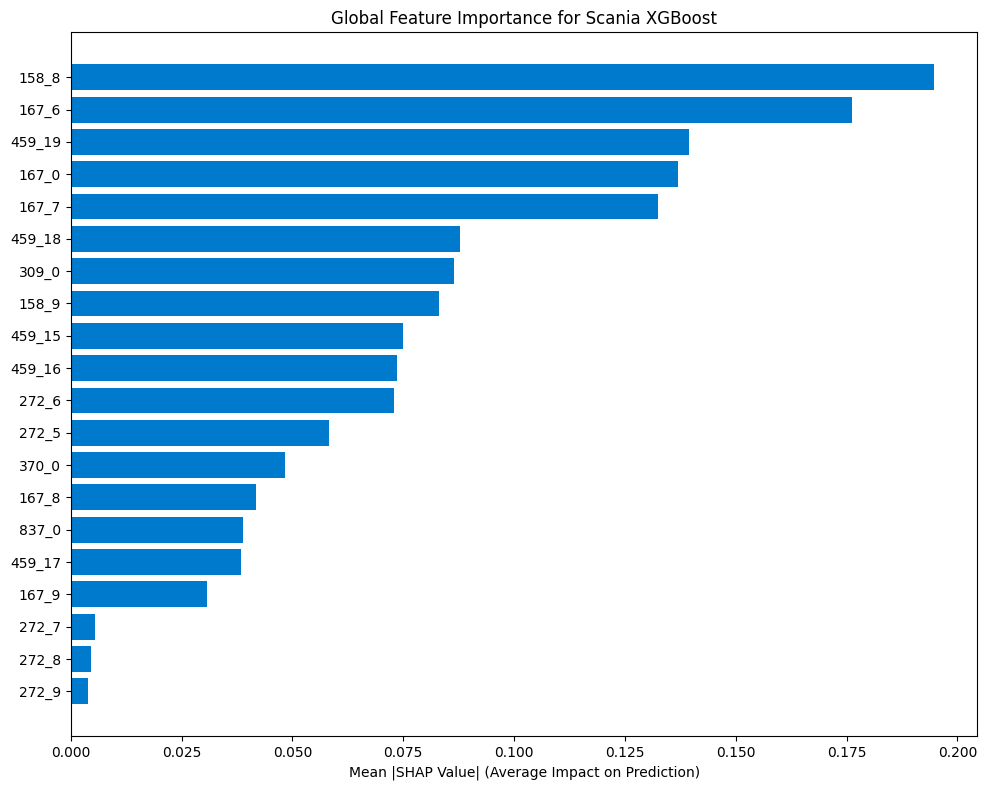

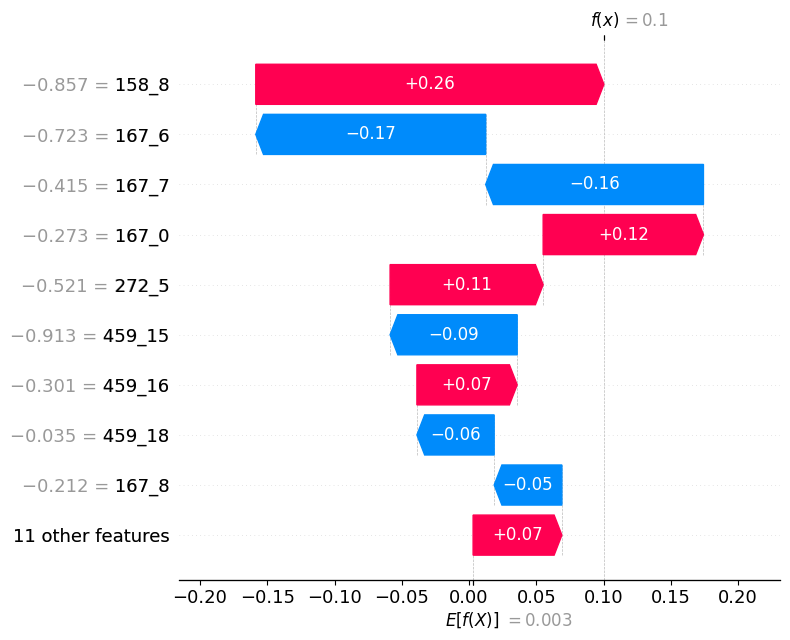

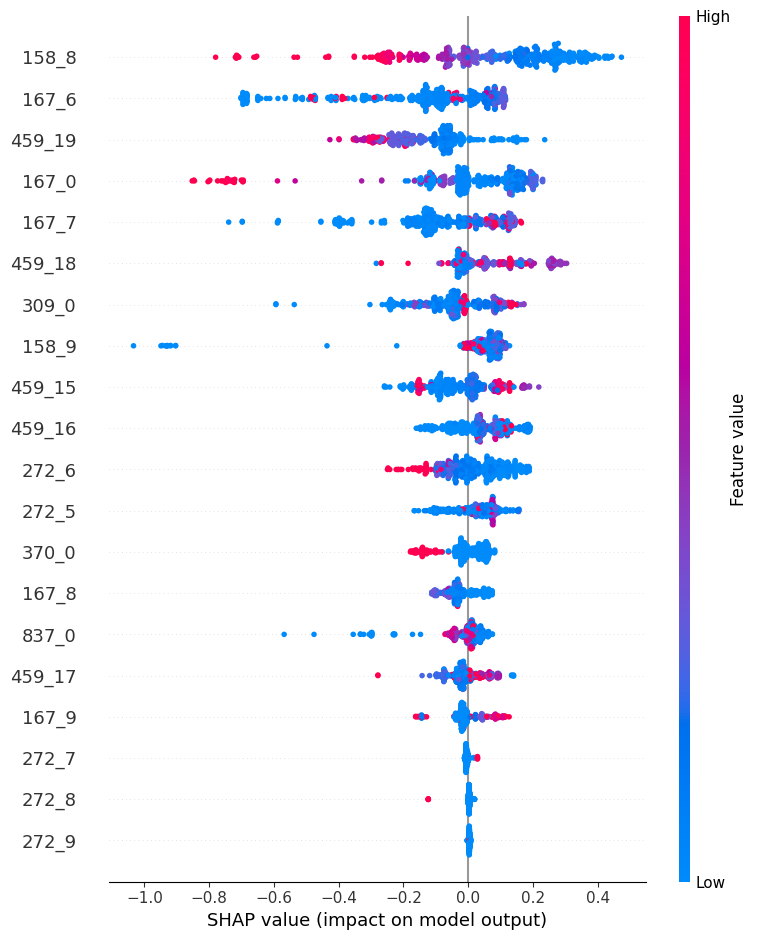

In [16]:
import shap
import matplotlib.pyplot as plt

# TreeExplainer is the correct and fastest explainer for XGBoost
explainer   = shap.TreeExplainer(model)
X_val_sample = X_val[:500]  # use 500 samples for speed
shap_values  = explainer.shap_values(X_val_sample)

# ── Plot 1: Global Feature Importance Bar Chart ──────────────────
global_shap     = np.abs(shap_values).mean(axis=0)
sorted_idx      = np.argsort(global_shap)
sorted_features = [top_20_features[i] for i in sorted_idx]
sorted_values   = global_shap[sorted_idx]

plt.figure(figsize=(10, 8))
plt.barh(sorted_features, sorted_values, color='#007acc')
plt.xlabel('Mean |SHAP Value| (Average Impact on Prediction)')
plt.title('Global Feature Importance for Scania XGBoost')
plt.tight_layout()
plt.savefig('shap_global.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: Waterfall Plot (single prediction) ───────────────────
explanation = shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_val_sample[0],
    feature_names=top_20_features
)

plt.figure()
shap.plots.waterfall(explanation, show=False)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 3: Summary Beeswarm Plot ────────────────────────────────
shap.summary_plot(shap_values, X_val_sample,
                  feature_names=top_20_features, show=False)
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()